# Airbnb Athens Listing Analysis(EDA)

## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

## Data loading

In [2]:
listings = pd.read_csv('athens_listings.csv')
reviews = pd.read_csv('reviews.csv')

In [3]:
reviews

,listing_id,date
0,10595,2011-05-20
1,10595,2012-08-15
2,10595,2013-05-20
3,10595,2014-05-04
4,10595,2014-09-13
...,...,...
750958,1224705173691881761,2024-09-05
750959,1224726948273160551,2024-09-07
750960,1224726948273160551,2024-09-13
750961,1224726948273160551,2024-09-16


## Data cleaning

### Checking for missing values

In [3]:
print(listings.isnull().sum())

# Fill missing values (if applicable)
listings['name'].fillna('No Name', inplace=True)
listings['reviews_per_month'].fillna(0, inplace=True)

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group               14137
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                               427
minimum_nights                        0
number_of_reviews                     0
last_review                        1858
reviews_per_month                  1858
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                             202
dtype: int64


C:\Users\κική\AppData\Local\Temp\ipykernel_11528\2751709751.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  listings['name'].fillna('No Name', inplace=True)
C:\Users\κική\AppData\Local\Temp\ipykernel_11528\2751709751.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

### Handling Duplicates

In [4]:
listings.drop_duplicates(inplace=True)

### Fixing Data Types

In [5]:
listings['last_review'] = pd.to_datetime(listings['last_review'], errors='coerce')

## Overall Summary

### How many listings are there?

In [6]:
print(f"Total listings: {listings.shape[0]}")

Total listings: 14137


### Distribution of room types

<Axes: title={'center': 'Room Type Distribution (Athens)'}, xlabel='room_type'>

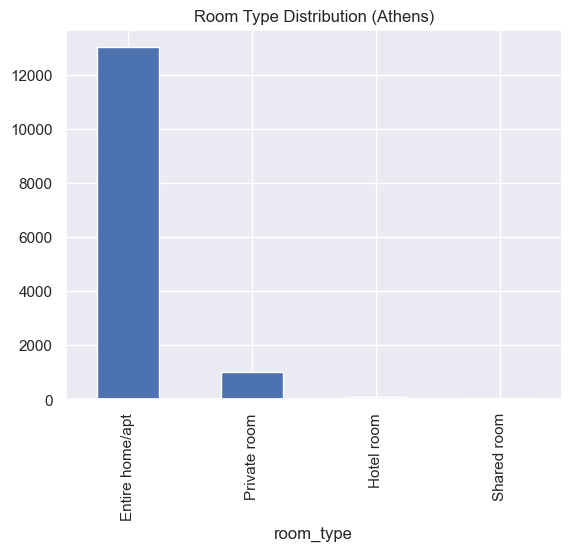

In [8]:
sns.set_theme()
room_type_counts = listings['room_type'].value_counts()
room_type_counts.plot(kind='bar', title='Room Type Distribution (Athens)')

As it is seen above, most people prefer to rent an apartment instead of a private room

## Pricing Terms

### Distribution of prices

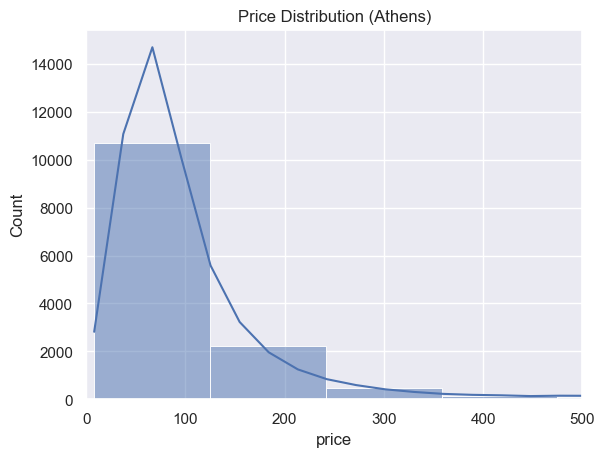

In [9]:
sns.set_theme()
sns.histplot(listings['price'], bins=50, kde=True)
plt.xlim(0, 500)
plt.title('Price Distribution (Athens)')
plt.show()

As it is seen above, the average price is about 60 euros 

### Average price by neighborhood

<Axes: title={'center': 'Average Price by Neighborhood (Athens)'}, xlabel='neighbourhood'>

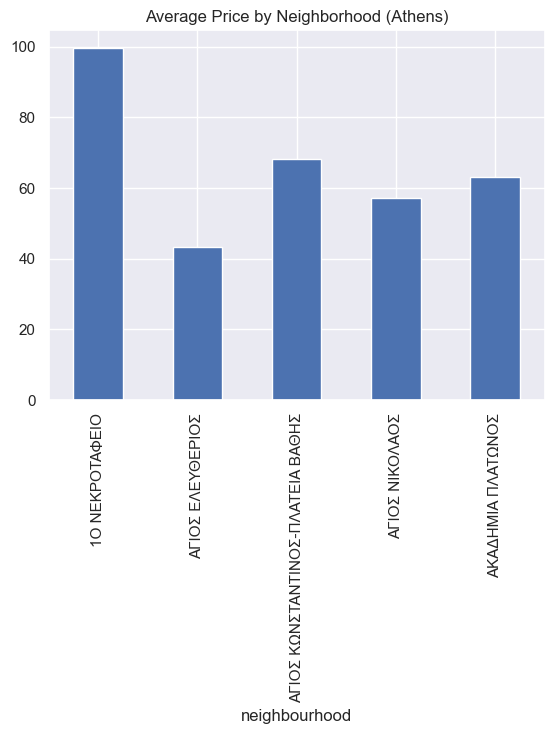

In [10]:
avg_price_neighborhood = listings.groupby('neighbourhood')['price'].mean()[:5]
avg_price_neighborhood.plot(kind='bar', title='Average Price by Neighborhood (Athens)')

## Geographical Analysis

### Visualize listings on a map

In [11]:
import folium
map_ath = folium.Map(location=[37.983810, 23.727539], zoom_start=10)
for _, row in listings.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=1,
        color='blue',
        fill=True
    ).add_to(map_ath)

map_ath.save("ath_listings_map.html")

### Listings by neighborhood

<Axes: title={'center': 'Listings by Neighborhood Group (Athens)'}, ylabel='count'>

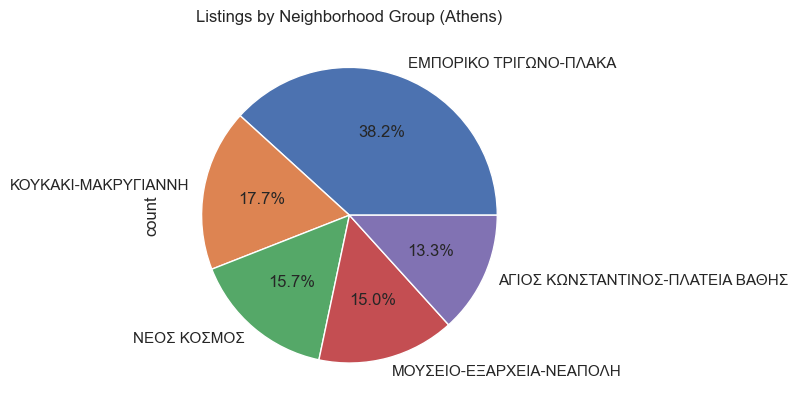

In [12]:
sns.set_theme()
neighborhood_counts = listings['neighbourhood'].value_counts().head()
neighborhood_counts.plot(kind='pie', autopct='%1.1f%%', title='Listings by Neighborhood Group (Athens)')

## Availability and Reviews

### Distribution of minimum nights

C:\Users\κική\AppData\Local\Temp\ipykernel_4504\2193330162.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=30)


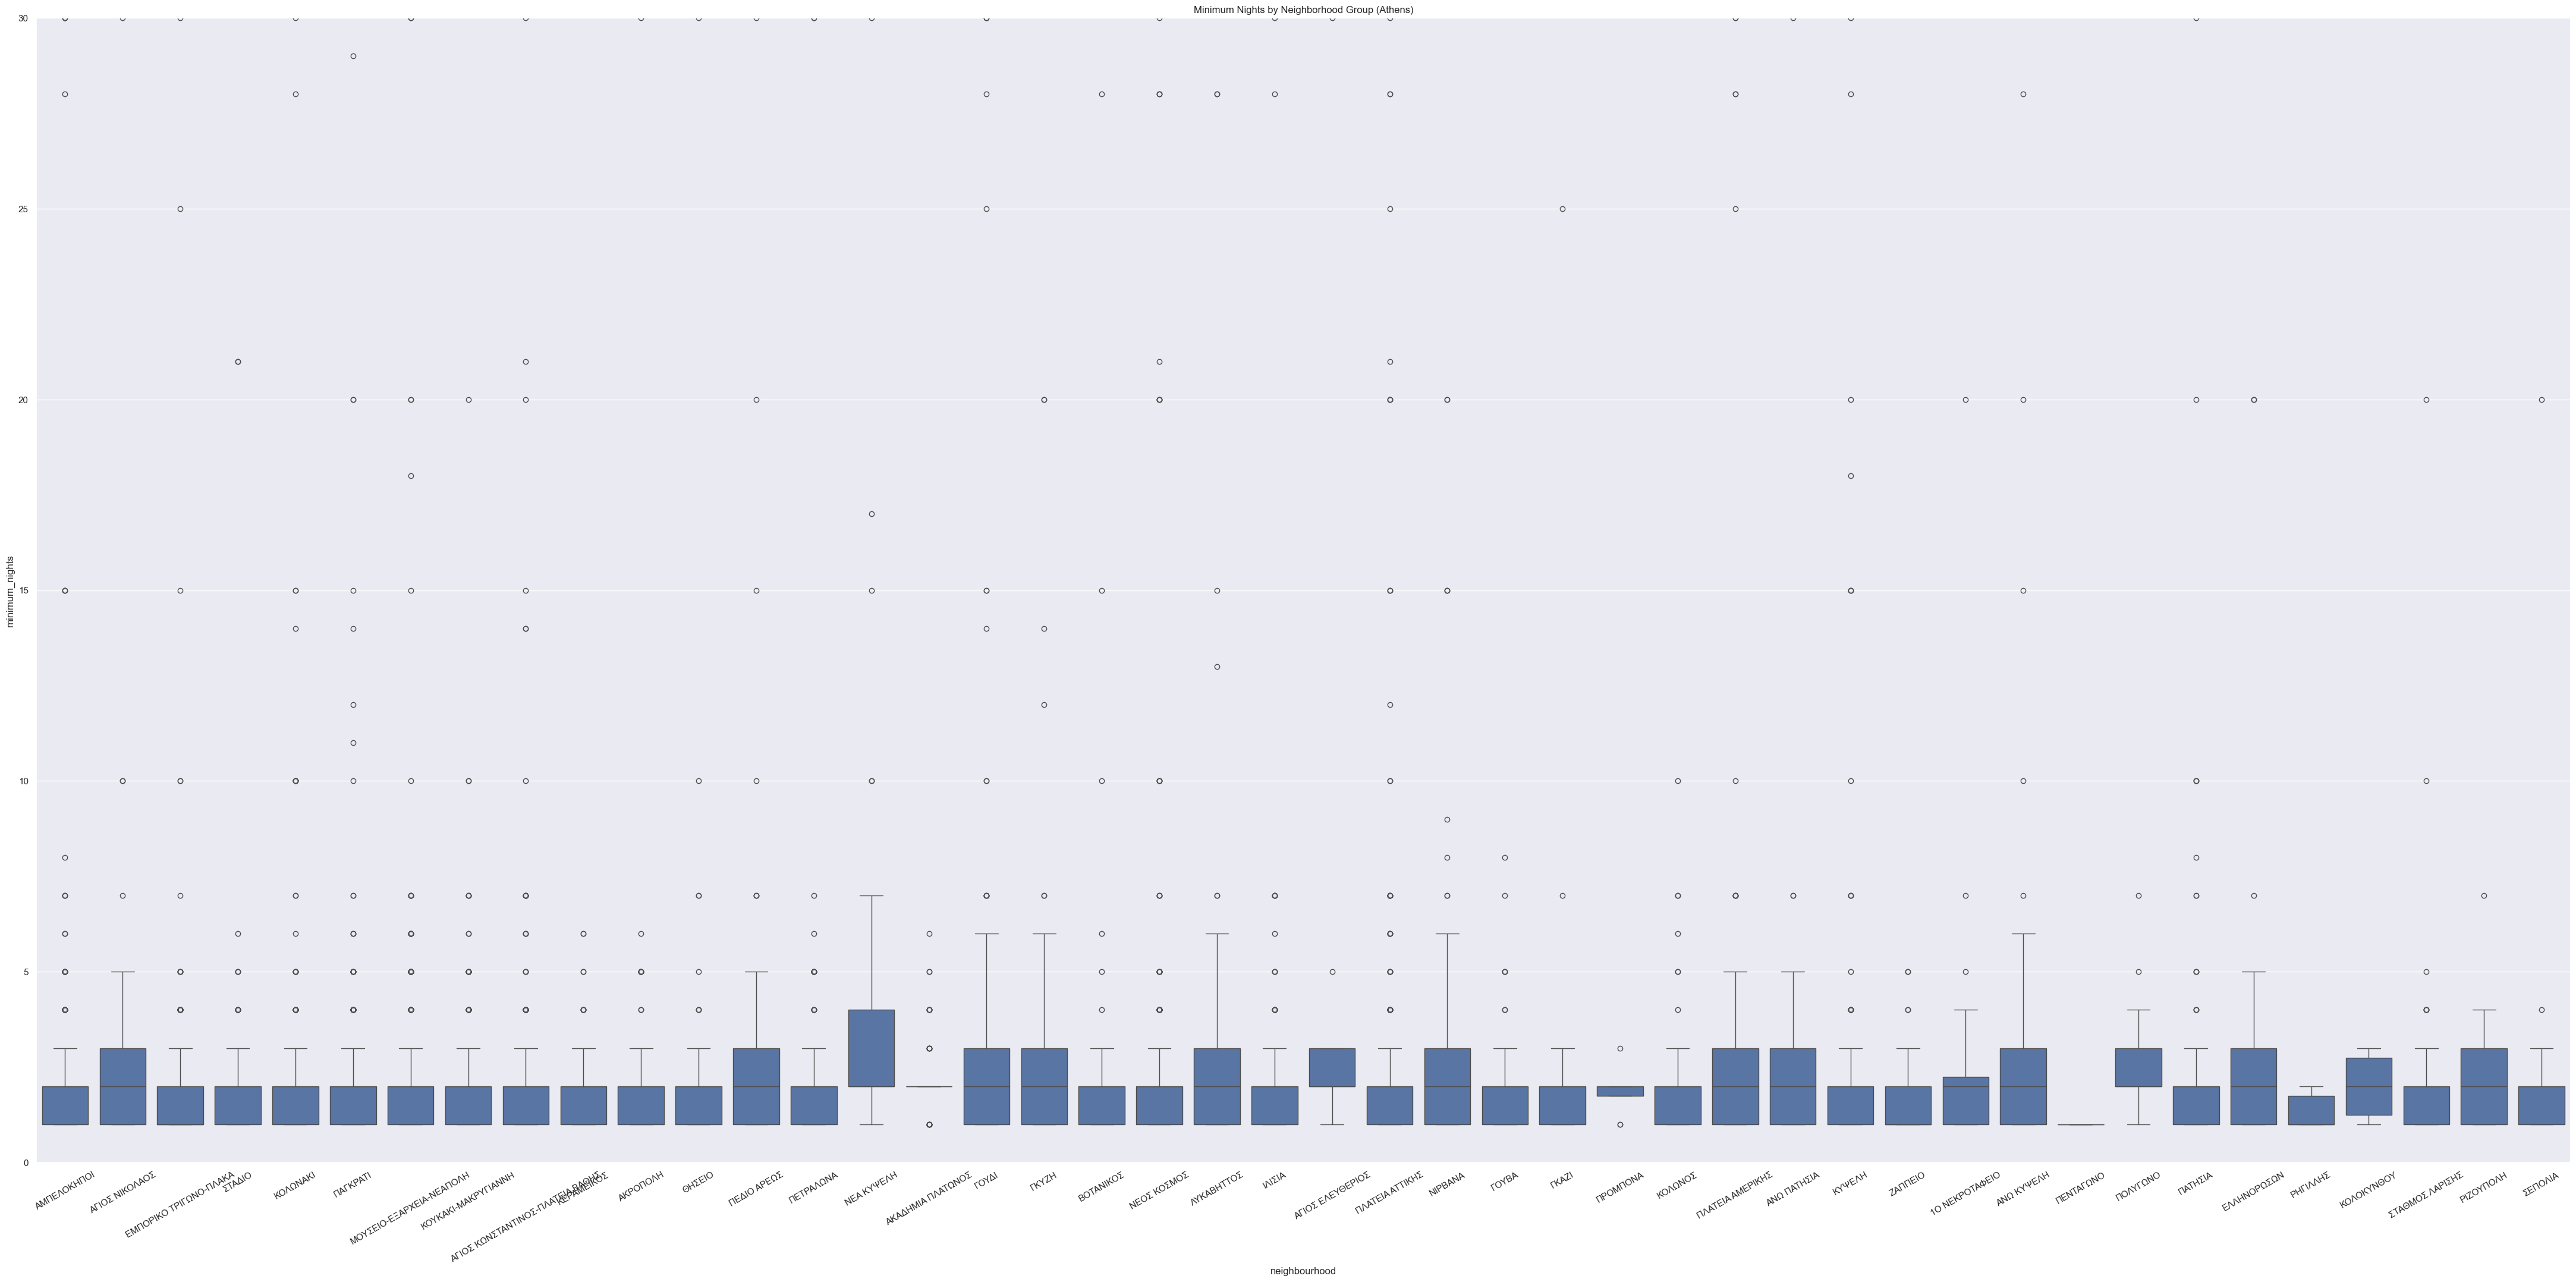

In [28]:
sns.set_theme()
plt.figure(figsize=(55,25))
ax = sns.boxplot(x='neighbourhood', y='minimum_nights', data=listings)
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)
plt.ylim(0, 30)
plt.title('Minimum Nights by Neighborhood Group (Athens)')
plt.show()

### Reviews per month

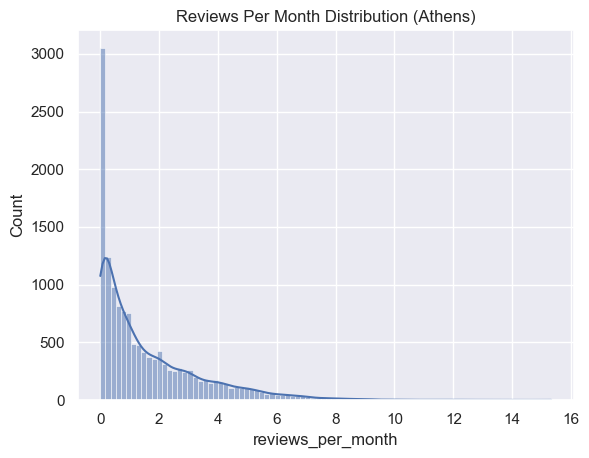

In [14]:
sns.set_theme()
sns.histplot(listings['reviews_per_month'], kde=True)
plt.title('Reviews Per Month Distribution (Athens)')
plt.show()

### Availability based on minimum nights

<Axes: title={'center': 'Availability by minimum nights (Athens)'}, xlabel='minimum_nights'>

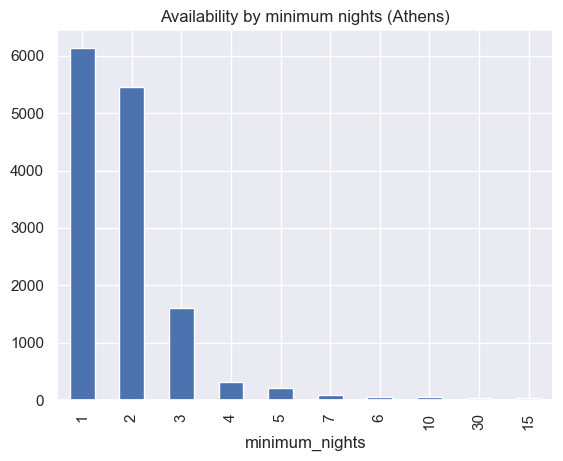

In [15]:
sns.set_theme()
m_nights = listings['minimum_nights'].value_counts().head(10)
m_nights.plot(kind='bar', title='Availability by minimum nights (Athens)')

### Reviews and lower prices 

In [16]:
listings[['number_of_reviews','price']].value_counts().head(20)
# listings['number_of_reviews'].value_counts(ascending=True)
#.value_counts(ascending=True).head(50)

number_of_reviews  price
0                  80.0     45
                   50.0     42
                   60.0     37
                   70.0     35
                   40.0     32
                   64.0     31
1                  60.0     27
0                  90.0     27
                   120.0    27
                   45.0     26
                   100.0    26
1                  50.0     23
2                  50.0     23
0                  65.0     23
                   85.0     23
2                  60.0     23
0                  500.0    22
1                  35.0     22
0                  55.0     21
5                  60.0     21
Name: count, dtype: int64

### Room Type

In [17]:
rtype = listings['room_type'].value_counts()
rtype
# rtype.plot(kind='bar', title="Room Type")

room_type
Entire home/apt    13001
Private room        1007
Hotel room            74
Shared room           55
Name: count, dtype: int64

### Last review varies across neighbour

In [18]:
sns.set_theme()
last_neigh = listings.groupby('neighbourhood')['last_review'].value_counts()
last_neigh
# sns.histplot(last_neigh)
# plt.title('Reviews Per Month Distribution')
# plt.show()

neighbourhood    last_review
1Ο ΝΕΚΡΟΤΑΦΕΙΟ   2024-09-08     4
                 2024-09-19     4
                 2024-09-07     2
                 2024-09-12     2
                 2024-09-13     2
                               ..
ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ  2024-09-07     1
                 2024-09-08     1
                 2024-09-13     1
                 2024-09-14     1
                 2024-09-20     1
Name: count, Length: 4745, dtype: int64

### Analyse trends over time based on last review

In [7]:
listings = listings.dropna(subset=['last_review'])

In [8]:
# Group by 'neighbourhood' and calculate review trends
review_trends = listings.groupby(['neighbourhood', 'last_review']).size().reset_index(name='review_count')

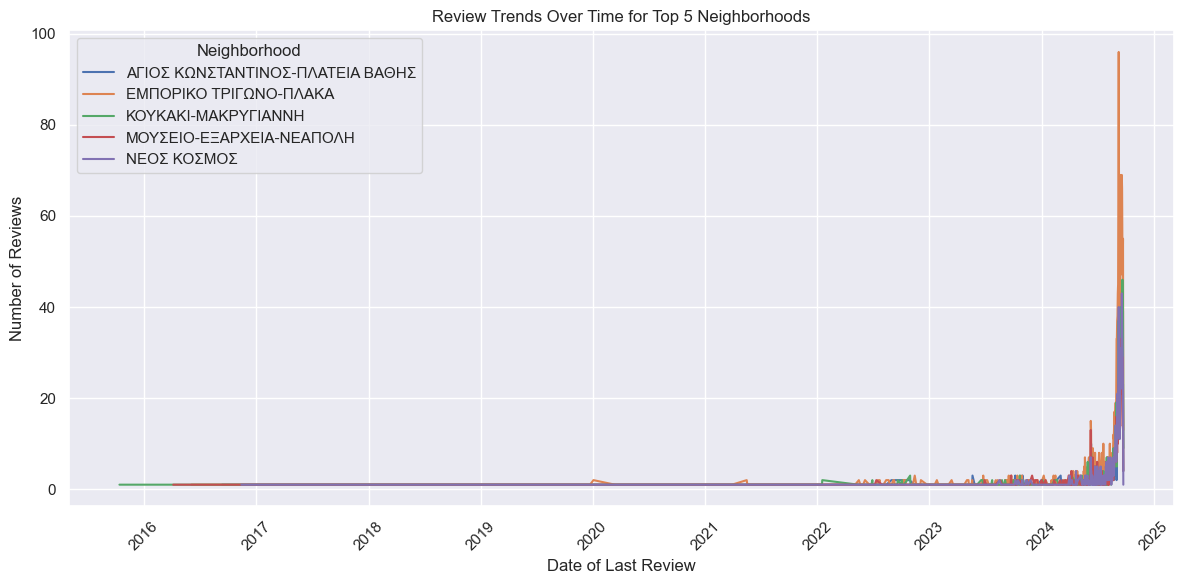

In [9]:
# Visualize review trends over time for the top 5 neighborhoods by total reviews
top_neighborhoods = listings.groupby('neighbourhood')['number_of_reviews'].sum().nlargest(5).index
filtered_trends = review_trends[review_trends['neighbourhood'].isin(top_neighborhoods)]

sns.set_theme()
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_trends,
    x='last_review',
    y='review_count',
    hue='neighbourhood'
)
plt.title('Review Trends Over Time for Top 5 Neighborhoods')
plt.xlabel('Date of Last Review')
plt.ylabel('Number of Reviews')
plt.legend(title='Neighborhood')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

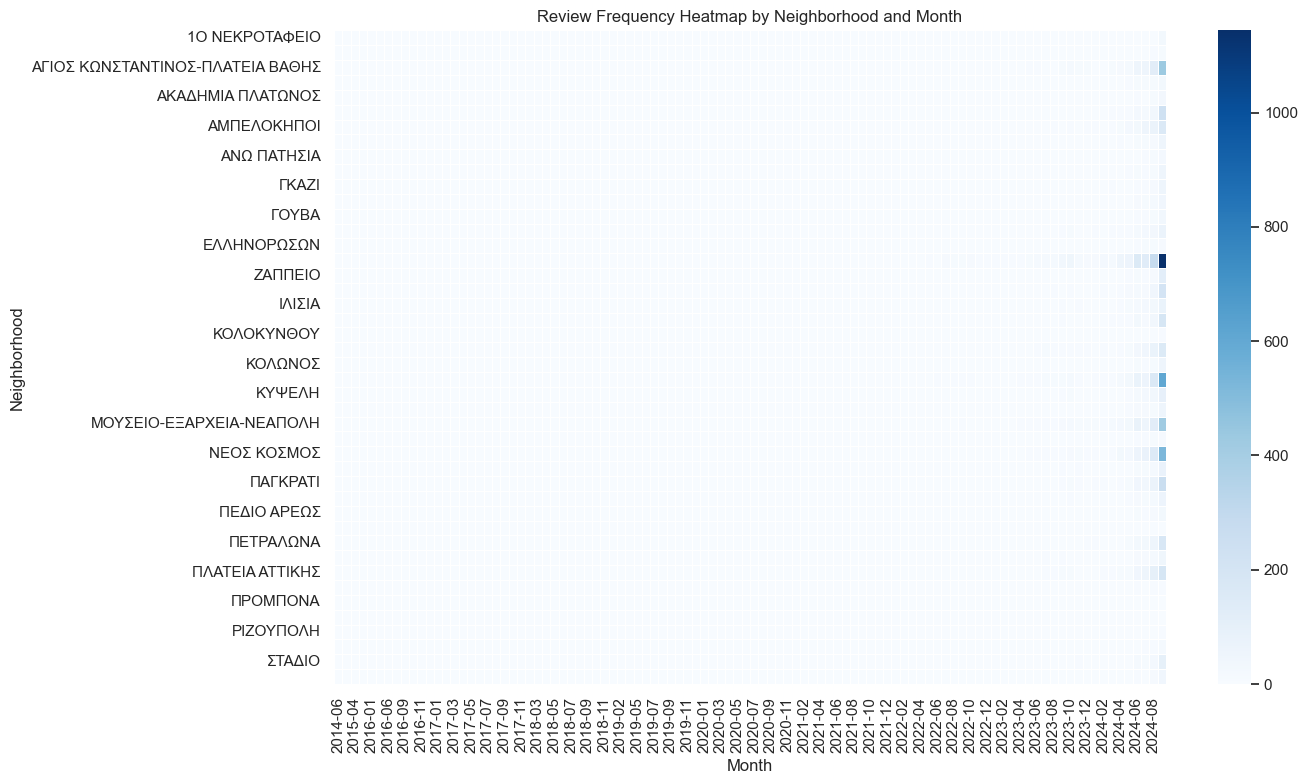

In [10]:
# Heatmap of review frequency by neighborhood and month
listings['month'] = listings['last_review'].dt.to_period('M')
heatmap_data = listings.groupby(['neighbourhood', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.5)
plt.title('Review Frequency Heatmap by Neighborhood and Month')
plt.xlabel('Month')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()